# MNIST Digit Recognition Using CNN (Convolutional Neural Network)

Lucky Singh
202401100300146

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import gzip
import urllib.request
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(60000, 28, 28) (60000,)


In [7]:
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0
print(X_train.shape)
(60000, 784)
def one_hot(y, num_classes=10):
    onehot = np.zeros((y.size, num_classes))
    onehot[np.arange(y.size), y] = 1
    return onehot
y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return (x > 0).astype(float)
def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)
input_size = 784
hidden_size = 128
output_size = 10
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))
def forward(X):
    global Z1, A1, Z2, A2
    
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    
    return A2
def compute_loss(y_pred, y_true):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss
def backward(X, y_true, y_pred, lr=0.01):
    global W1, b1, W2, b2
    
    m = X.shape[0]
    dZ2 = y_pred - y_true
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
epochs = 10
batch_size = 64
lr = 0.01
for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_onehot[i:i+batch_size]
        y_pred = forward(X_batch)
        loss = compute_loss(y_pred, y_batch)
        backward(X_batch, y_batch, y_pred, lr)
    print("Epoch:", epoch+1, "Loss:", loss)

(60000, 784)
Epoch: 1 Loss: 0.9844689749773434
Epoch: 2 Loss: 0.391182609924582
Epoch: 3 Loss: 0.2683026916525998
Epoch: 4 Loss: 0.21583295620349963
Epoch: 5 Loss: 0.18597048504570768
Epoch: 6 Loss: 0.16663936460633655
Epoch: 7 Loss: 0.15256867441669084
Epoch: 8 Loss: 0.14101660354233814
Epoch: 9 Loss: 0.13182537927823623
Epoch: 10 Loss: 0.12281193888763632


### Normalize and reshape to (samples, 28, 28, 1)

In [8]:
epochs = 10
batch_size = 64
lr = 0.01
for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_onehot[i:i+batch_size]
        y_pred = forward(X_batch)
        loss = compute_loss(y_pred, y_batch)
        backward(X_batch, y_batch, y_pred, lr)
    print("Epoch:", epoch+1, "Loss:", loss)


Epoch: 1 Loss: 0.11435849808926626
Epoch: 2 Loss: 0.10686802094221537
Epoch: 3 Loss: 0.10042740963900271
Epoch: 4 Loss: 0.09461852086745215
Epoch: 5 Loss: 0.08953141944648155
Epoch: 6 Loss: 0.08492569744277778
Epoch: 7 Loss: 0.08069747685162669
Epoch: 8 Loss: 0.07688939903970454
Epoch: 9 Loss: 0.0733971052927835
Epoch: 10 Loss: 0.07007516359314928


### Build CNN model

In [12]:
def predict(X):
    y_pred = forward(X)
    return np.argmax(y_pred, axis=1)
predictions = predict(X_test)
accuracy = np.mean(predictions == y_test)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.941


### Training and saving training accuracy and loss

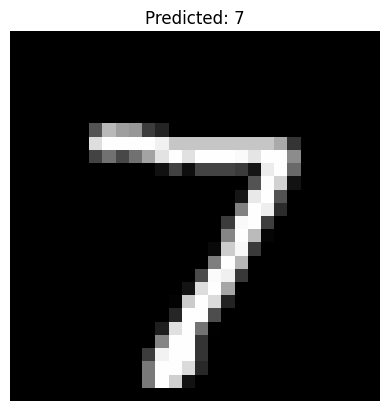

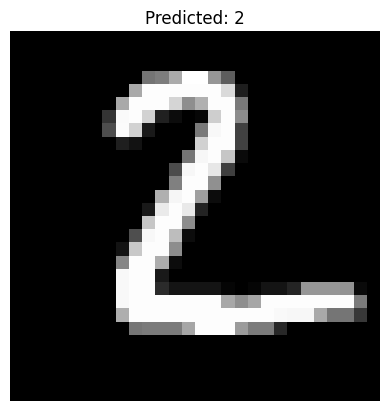

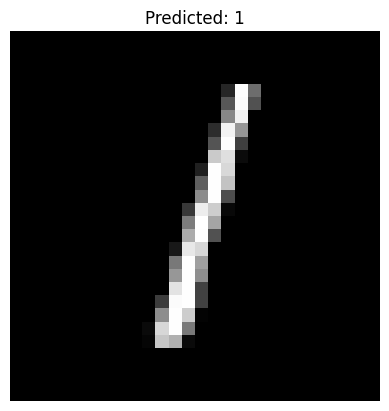

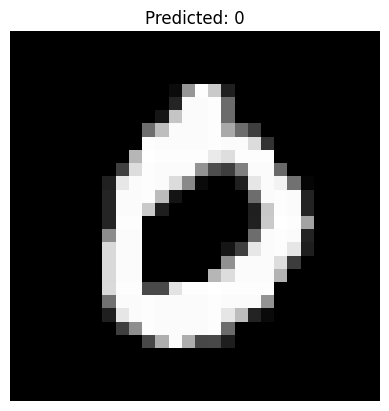

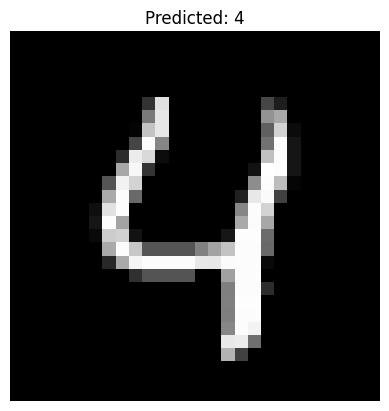

In [13]:
for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Predicted: " + str(predictions[i]))
    plt.axis('off')
    plt.show()